generating white noise

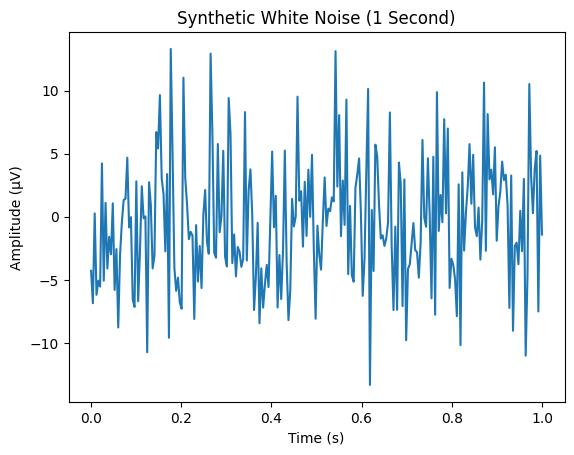

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define your synthetic EEG parameters
sampling_rate = 250 # Hz (samples per second)
duration = 10       # seconds
num_samples = sampling_rate * duration

# 2. Define the noise characteristics
mean_voltage = 0    # The signal centers around 0 microvolts
amplitude = 5       # The standard deviation (controls how "loud" the noise is)

# 3. Generate the white noise
white_noise = np.random.normal(mean_voltage, amplitude, num_samples)

# Optional: Plot a 1-second snippet to visualize
time = np.linspace(0, 1, sampling_rate)
plt.plot(time, white_noise[:sampling_rate])
plt.title("Synthetic White Noise (1 Second)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (µV)")
plt.show()

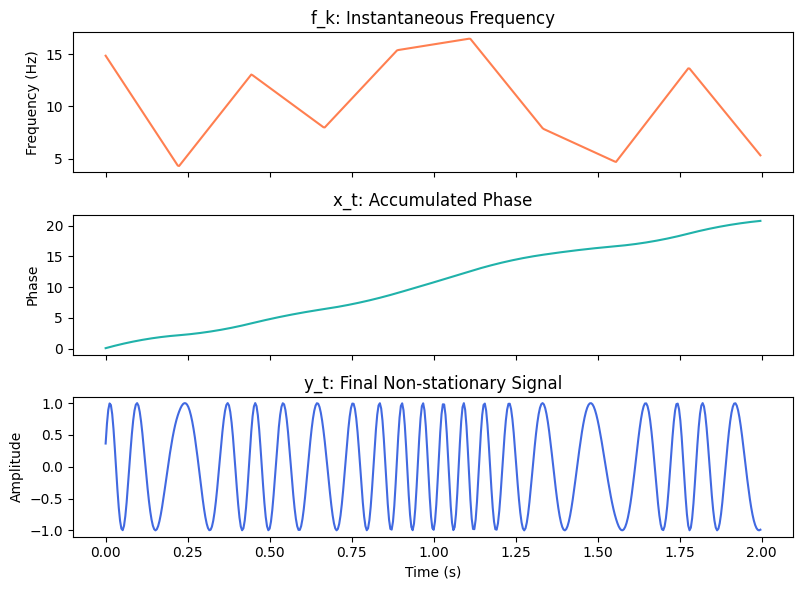

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# 1. Setup Parameters
sampling_rate = 250        # Hz
delta = 1 / sampling_rate  # Time step (delta)
duration = 2.0             # Seconds
t = np.arange(0, duration, delta)

# 2. Generate non-stationary frequency f_k (Top Graph)
# Create random "waypoints" for the frequency to wander between
num_waypoints = 10
t_waypoints = np.linspace(0, duration, num_waypoints)
f_waypoints = np.random.uniform(2, 18, num_waypoints)

# Interpolate to get a specific frequency value for every time step
interp_func = interp1d(t_waypoints, f_waypoints, kind='linear')
f_k = interp_func(t)

# 3. Calculate the phase integral x_t (Middle Graph)
# x_t = delta * sum(f_k)
x_t = delta * np.cumsum(f_k)

# 4. Generate the final signal y_t (Bottom Graph)
# y_t = sin(2 * pi * x_t)
y_t = np.sin(2 * np.pi * x_t)

# --- Plotting the Results to Match Your Image ---
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(8, 6), sharex=True)

ax1.plot(t, f_k, color='coral')
ax1.set_ylabel('Frequency (Hz)')
ax1.set_title('f_k: Instantaneous Frequency')

ax2.plot(t, x_t, color='lightseagreen')
ax2.set_ylabel('Phase')
ax2.set_title('x_t: Accumulated Phase')

ax3.plot(t, y_t, color='royalblue')
ax3.set_ylabel('Amplitude')
ax3.set_title('y_t: Final Non-stationary Signal')
ax3.set_xlabel('Time (s)')

plt.tight_layout()
plt.show()

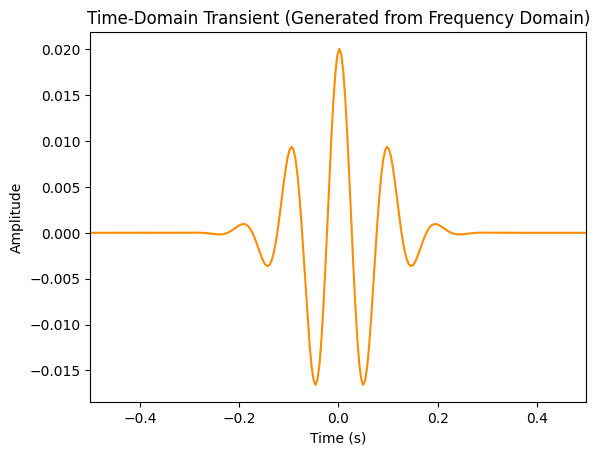

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Setup Parameters
sampling_rate = 250
duration = 2.0
num_samples = int(sampling_rate * duration)
time = np.linspace(-duration/2, duration/2, num_samples)

# 2. Define the Frequency Domain Gaussian
peak_freq = 10.0      # Center the bump at 10 Hz
freq_width = 2.0      # How wide the frequency bump is (sigma_f)

# Create an array of frequencies
frequencies = np.fft.fftfreq(num_samples, d=1/sampling_rate)

# Build the Gaussian curve directly in the frequency domain
# Formula: e^(-(f - peak_f)^2 / (2 * sigma_f^2))
freq_gaussian = np.exp(-((frequencies - peak_freq)**2) / (2 * freq_width**2))

# 3. Transform to the Time Domain
# We use standard ifft and take the real part to get our physical signal
time_transient = np.real(np.fft.ifft(freq_gaussian))

# Shift the result so the transient is centered in our time window
time_transient = np.fft.fftshift(time_transient)

# Plotting
plt.plot(time, time_transient, color='darkorange')
plt.title("Time-Domain Transient (Generated from Frequency Domain)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.xlim(-0.5, 0.5) # Zoom in on the wavelet
plt.show()

In [ ]:
import numpy as np
from scipy import signal

# Assume 'eeg_data' is your 1D array of raw voltages
# Assume 'wavelet' is your 1D array of the Morlet wavelet you generated

# Run the convolution
# mode='same' ensures the output array is the exact same length as your EEG data
convolution_result = signal.convolve(eeg_data, wavelet, mode='same')

# To get the actual Power (magnitude), you take the absolute value squared
power_10hz = np.abs(convolution_result)**2

NameError: name 'eeg_data' is not defined

signal processing proper
(from MNE dataset)

In [ ]:
# 1. Install MNE (You must do this every time)
!pip install mne

import mne
import numpy as np
from google.colab import drive
import os

# 2. Mount your Google Drive (A popup will ask for your permission)
drive.mount('/content/drive')

# 3. Create a permanent folder in your Drive for EEG data
drive_path = '/content/drive/MyDrive/EEG_Data'
os.makedirs(drive_path, exist_ok=True)

# 4. Tell MNE to look in your Drive.
# If it's your first time, it downloads it here.
# Next time, it sees it's already there and loads it instantly!
sample_data_folder = mne.datasets.sample.data_path(path=drive_path)

# 5. Load the file
raw_file = sample_data_folder / 'MEG' / 'sample' / 'sample_audvis_raw.fif'
raw = mne.io.read_raw_fif(raw_file, preload=True)

# 2. Epoch the data (Turn 2D into 3D)
# Find the digital triggers sent to the EEG when a stimulus happened
events = mne.find_events(raw)


#remove all sorts of shit in data before going to epoch
raw.filter(l_freq=0.1,h_freq=40.0)
# Let's extract only the trials where the patient heard a sound in their left ear
event_id = {'Auditory/Left': 1}
epochs = mne.Epochs(raw, events, event_id, tmin=-0.2, tmax=0.5, preload=True)

# 3. The Extraction
# This extracts the underlying 3D NumPy matrix.
data_matrix = epochs.get_data()

print(f"Full 3D Matrix Shape: {data_matrix.shape}")
# Output: (72, 376, 106)
# -> 72 Trials, 376 Channels (EEG+MEG), 106 Time points (samples) per trial



# Keep only the EEG channels, drop the MEG channels
raw.pick_types(meg=False, eeg=True, eog=True)


# 4. The Slice
# Let's extract Channel index 15 (which might be 'EEG 015') across ALL trials and ALL time.
channel_15_data = data_matrix[:, 15, :]

print(f"Extracted 2D Shape: {channel_15_data.shape}")
# Output: (72, 106)
# -> You now have a 2D matrix of just one electrode.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 45.2 MB/s eta 0:00:00
Mounted at /content/drive


  0%|                                              | 0.00/1.65G [00:00<?, ?B/s]

Untarring contents of '/content/drive/MyDrive/EEG_Data/MNE-sample-data-processed.tar.gz' to '/content/drive/MyDrive/EEG_Data'


Attempting to create new mne-python configuration file:
/root/.mne/mne-python.json
Could not read the /root/.mne/mne-python.json json file during the writing. Assuming it is empty. Got: Expecting value: line 1 column 1 (char 0)
Download complete in 05m49s (1576.2 MB)
Opening raw data file /content/drive/MyDrive/EEG_Data/MNE-sample-data/MEG/sample/sample_audvis_raw.fif...
    Read a total of 3 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
    Range : 25800 ... 192599 =     42.956 ...   320.670 secs
Ready.
Reading 0 ... 166799  =      0.000 ...   277.714 secs...
Finding events on: STI 014
320 events found on stim channel STI 014
Event IDs: [ 1  2  3  4  5 32]
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194

Applying baseline correction (mode: logratio)


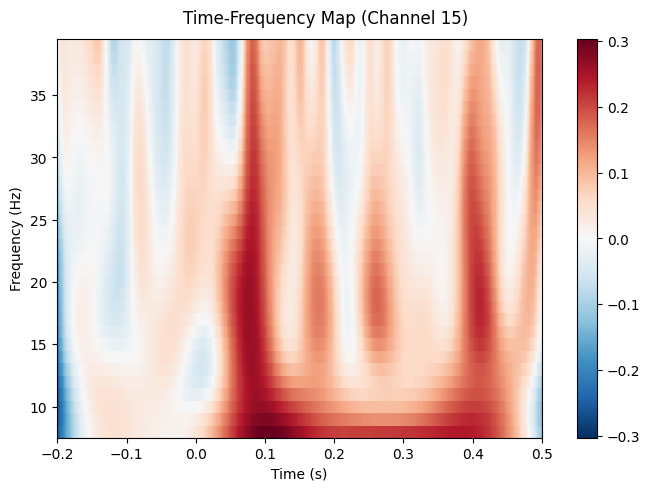

[<Figure size 640x480 with 2 Axes>]

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Start at 8 Hz so the physical wave and its tails fit in 0.7s
frequencies = np.arange(8, 40, 1)

# 2. Use a fixed, tight 3-cycle Gaussian envelope
cycles = 3

# 3. The Modern MNE Computation
# average=True collapses the 72 trials into one clean 2D map
tfr_power = epochs.compute_tfr(
    method="morlet",
    freqs=frequencies,
    n_cycles=cycles,
    return_itc=False,
    average=True
)

# 4. Plot the 2D Heatmap
# picks=[15] targets our specific channel.
# baseline=(-0.2, 0) subtracts the pre-beep resting state.
tfr_power.plot(
    picks=[15],
    baseline=(-0.2, 0),
    mode='logratio',
    title="Time-Frequency Map (Channel 15)"
)

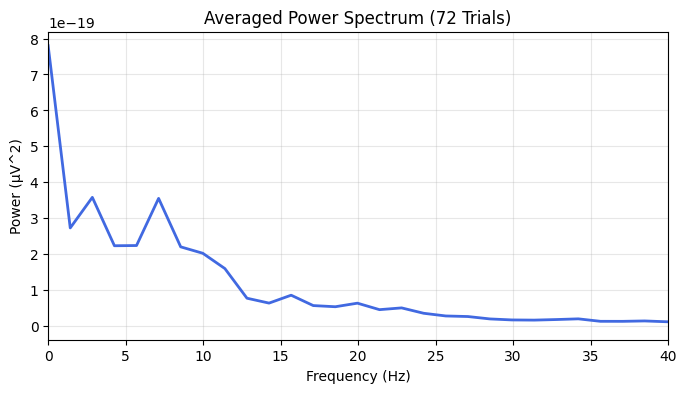

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Assume channel_data is your extracted (72, 421) NumPy array
# Assuming the MNE sample rate of 600 Hz
sampling_rate = 600
num_samples = channel_15_data.shape[1] # 421

# 1. Run the FFT across the time axis (axis=1)
# The output shape will be (72, 212) because rfft only returns the positive frequencies
fft_results = np.fft.rfft(channel_15_data, axis=1)


# 2. THE FIX: Keep only the EEG channels (drop the MEG)
raw.pick(['eeg', 'stim']) # We keep 'stim' because it holds the event triggers!


# 2. Extract the Power
# Magnitude squared = Power
power_matrix = np.abs(fft_results)**2

# 3. Average across all 72 trials (axis=0 points down the columns)
# This collapses the shape from (72, 212) down to just (212,)
average_power = np.mean(power_matrix, axis=0)

# 4. Generate the x-axis (Frequencies)
frequencies = np.fft.rfftfreq(num_samples, d=1/sampling_rate)

# Plotting
plt.figure(figsize=(8, 4))
plt.plot(frequencies, average_power, color='royalblue', linewidth=2)
plt.title("Averaged Power Spectrum (72 Trials)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power (µV^2)")

# Zoom in on the biologically relevant frequencies (e.g., Delta to low Gamma)
plt.xlim(0, 40)
plt.grid(True, alpha=0.3)
plt.show()

MIKE X COHEN ASSIGNMENT

In [ ]:
import mne

# 1. Load the continuous data
sample_data_folder = mne.datasets.sample.data_path()
raw_file = sample_data_folder / 'MEG' / 'sample' / 'sample_audvis_raw.fif'
raw = mne.io.read_raw_fif(raw_file, preload=True)

# 2. THE FIX: Keep only the EEG channels (drop the MEG)
raw.pick(['eeg', 'stim']) # We keep 'stim' because it holds the event triggers!

# Check how many channels we have now
print(f"Total EEG Channels: {len(raw.ch_names)}")

# 3. THE FIX: Filter the continuous data FIRST (0.1 Hz to 40 Hz)
raw.filter(l_freq=0.1, h_freq=40.0)

# 4. Find events and chop into Epochs
events = mne.find_events(raw)
event_id = {'Auditory/Left': 1}

# Extract the 700ms window (-200ms to 500ms)
epochs = mne.Epochs(raw, events, event_id, tmin=-0.2, tmax=0.5, preload=True)

# 5. Look at the final, corrected 3D Matrix
data_matrix = epochs.get_data()
print(f"Corrected 3D Matrix Shape: {data_matrix.shape}")

ModuleNotFoundError: No module named 'mne'

No projector specified for this dataset. Please consider the method self.add_proj.


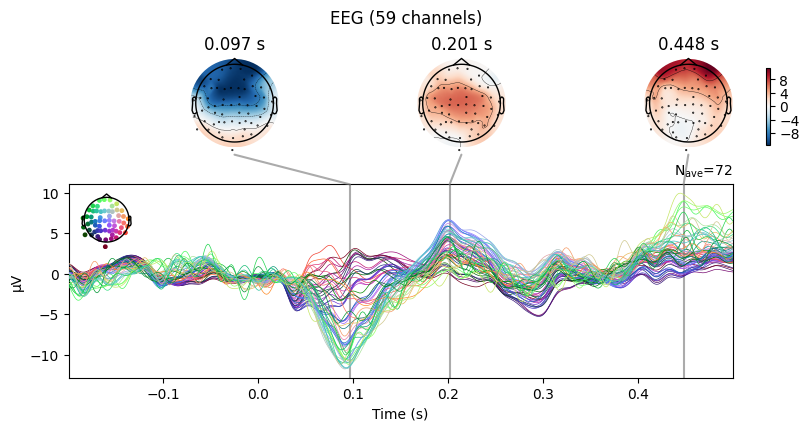

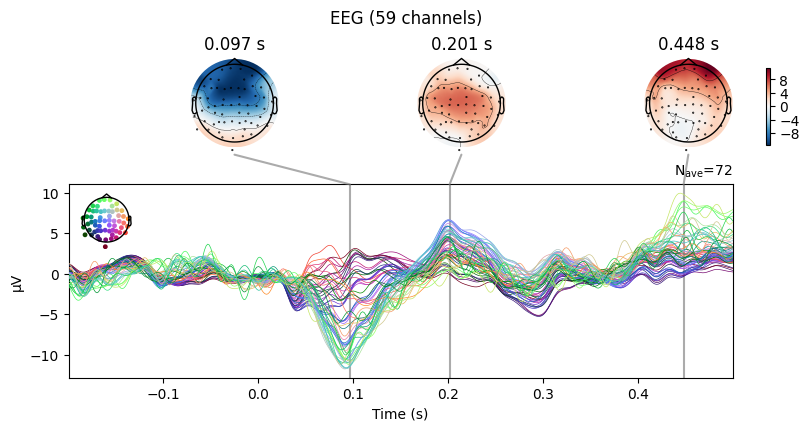

In [ ]:
evoked = epochs.average()
evoked.plot_joint()

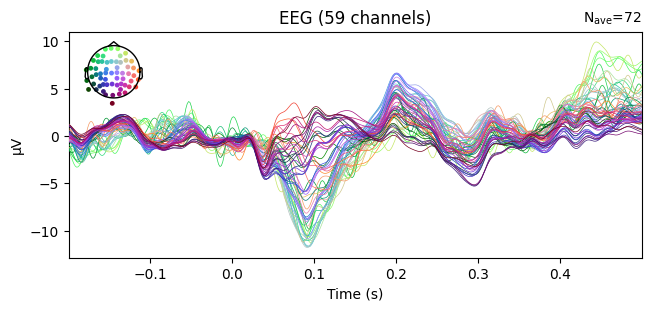

In [ ]:
evoked.plot(spatial_colors=True);

In [ ]:
import mne

# ==========================================
# STEP 1: LOAD & CLEAN THE CONTINUOUS DATA
# ==========================================

# 1a. Load the raw file into RAM
sample_data_folder = mne.datasets.sample.data_path()
raw_file = sample_data_folder / 'MEG' / 'sample' / 'sample_audvis_raw.fif'
raw = mne.io.read_raw_fif(raw_file, preload=True)

# 1b. Drop MEG channels, keep only electrical EEG and the Trigger cable
raw.pick(['eeg', 'stim'])

# 1c. Continuous Filtering (0.1 Hz to 40 Hz)
# Must be done BEFORE epoching to prevent ringing and edge artifacts!
raw.filter(l_freq=0.1, h_freq=40.0)

# 1d. Apply the Average Reference
# This centers the voltage to a "virtual ground" inside the head.
raw.set_eeg_reference('average')

# ==========================================
# STEP 2: EXTRACT & FILTER THE COGNITIVE TASK
# ==========================================

# 2a. Find the exact milliseconds the stimulus computer fired
events = mne.find_events(raw)
event_id = {'Auditory/Left': 1}

# 2b. Define the Artifact Rejection Threshold
# If any single electrode swings more than 150 µV during a trial,
# the patient likely blinked or squirmed. We tell Python to drop that trial.
reject_criteria = dict(eeg=150e-6) # 150 µV in Volts

# 2c. Slice the Epochs (-200ms to 500ms)
# This step automatically applies Baseline Correction (subtracting the -200ms to 0 average).
# It also automatically applies our rejection criteria.
epochs = mne.Epochs(raw, events, event_id,
                    tmin=-0.2, tmax=0.5,
                    reject=reject_criteria,
                    preload=True)

# ==========================================
# STEP 3: COLLAPSE & VISUALIZE
# ==========================================

# 3a. Average the surviving trials to reveal the Event-Related Potential
evoked = epochs.average()

# 3b. Plot the Butterfly Plot and Topographical Maps
evoked.plot_joint()

ModuleNotFoundError: No module named 'mne'

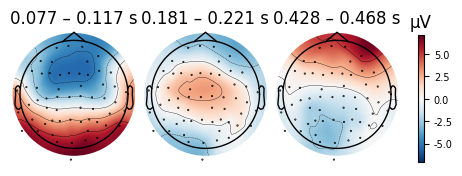

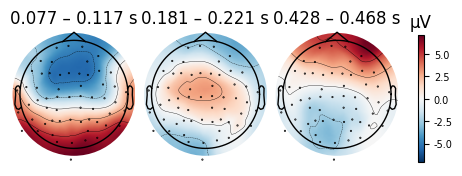

In [ ]:
# 1. Define the exact peak times you found (in seconds)
peak_times = [0.097, 0.201, 0.448]

# 2. Plot the maps with a 40ms smoothing window (0.040 seconds)
# MNE will automatically take 20ms before and 20ms after each time point.
evoked.plot_topomap(times=peak_times, average=0.040)

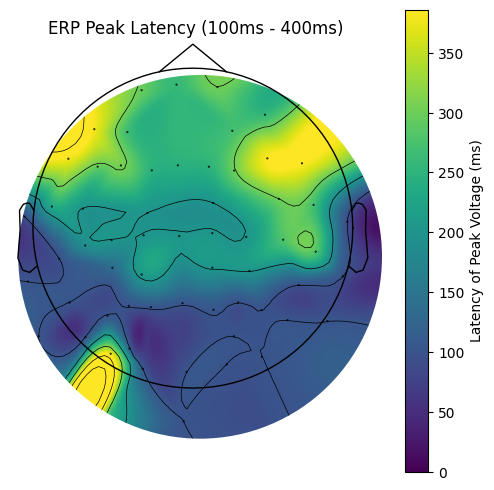

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. ISOLATE THE TIME WINDOW
# ==========================================
# We only care about 100ms to 400ms. We use copy() so we don't destroy our original evoked data.
evoked_window = evoked.copy().crop(tmin=0.1, tmax=0.4)

# Extract the underlying 2D NumPy array (Shape: 69 Channels x Timepoints)
data_matrix = evoked_window.data

# Extract the array of exact time points (in seconds)
time_array = evoked_window.times

# ==========================================
# 2. THE "FOR LOOP" (Finding the Peaks)
# ==========================================
# np.argmax looks across the time axis (axis=1) for every single channel.
# It returns the exact INDEX (e.g., sample #42) where the voltage was highest.
peak_indices = np.argmax(data_matrix, axis=1)

# Now we translate those index numbers into actual time in milliseconds.
# We map the index back to the time_array, and multiply by 1000.
peak_times_ms = time_array[peak_indices] * 1000

# ==========================================
# 3. BUILD THE GRAPH (The Hack)
# ==========================================
# We bypass the standard evoked plot and use the raw plotting engine.
fig, ax = plt.subplots(figsize=(6, 6))

# Feed it our custom array of milliseconds instead of microvolts
im, _ = mne.viz.plot_topomap(
    data=peak_times_ms,  # Our custom array of 69 time values
    pos=evoked.info,     # The spatial coordinates of where the electrodes are
    axes=ax,
    cmap='viridis',      # 'viridis' is a great color map for showing progression
    show=False
)

# Add the colorbar so we can actually read the milliseconds
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Latency of Peak Voltage (ms)')
plt.title('ERP Peak Latency (100ms - 400ms)')
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. EXTRACT 50 POINTS OF EEG DATA
# ==========================================
# Let's grab just 50 time points from the first trial, first channel
# 50 points at a 600Hz sampling rate is roughly an 80-millisecond snippet
eeg_snippet = data_matrix[0, 0, 100:150]

# ==========================================
# 2. CREATE THE KERNELS (Exercise 1)
# ==========================================
# Kernel A: The Inverted U (Symmetrical)
kernel_u = np.array([0.1, 0.4, 0.8, 1.0, 0.8, 0.4, 0.1])
# Scale it so the sum equals 1 (prevents the convolution from inflating the voltage)
kernel_u = kernel_u / np.sum(kernel_u)

# Kernel B: The Linear Decay (Asymmetrical)
kernel_decay = np.array([1.0, 0.8, 0.6, 0.4, 0.2, 0.0])
kernel_decay = kernel_decay / np.sum(kernel_decay)

# ==========================================
# 3. RUN THE CONVOLUTION (Exercise 2)
# ==========================================
# We use mode='same' to automatically handle the zero-padding and trimming
conv_u = np.convolve(eeg_snippet, kernel_u, mode='same')
conv_decay = np.convolve(eeg_snippet, kernel_decay, mode='same')

# ==========================================
# 4. PLOT THE RESULTS
# ==========================================
fig, axes = plt.subplots(3, 1, figsize=(8, 8), sharex=True)

# Plot 1: Raw Data
axes[0].plot(eeg_snippet, color='black', label='Raw EEG (50 points)', marker='.')
axes[0].legend()
axes[0].set_title('Original Data')

# Plot 2: Convolved with Inverted U
axes[1].plot(eeg_snippet, color='gray', alpha=0.5, linestyle='--')
axes[1].plot(conv_u, color='blue', label='Result: Inverted U Kernel', linewidth=2)
axes[1].legend()
axes[1].set_title('Symmetrical Convolution')

# Plot 3: Convolved with Decay
axes[2].plot(eeg_snippet, color='gray', alpha=0.5, linestyle='--')
axes[2].plot(conv_decay, color='red', label='Result: Decay Kernel', linewidth=2)
axes[2].legend()
axes[2].set_title('Asymmetrical Convolution')

plt.tight_layout()
plt.show()

NameError: name 'data_matrix' is not defined

signal processing

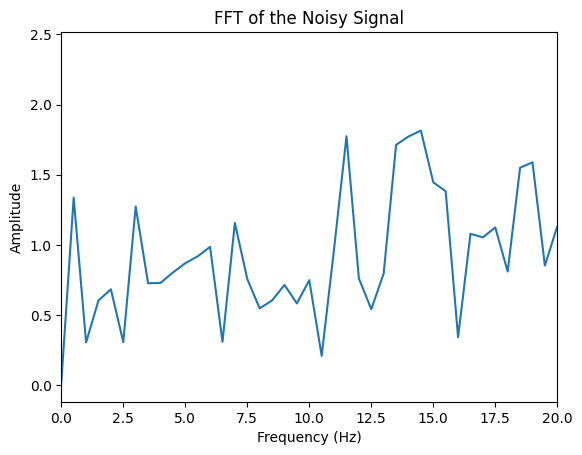

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define parameters for time and sampling rate
srate = 250 # Sampling rate in Hz
duration = 2.0 # Duration in seconds
num_samples = int(srate * duration)
time = np.linspace(0, duration, num_samples, endpoint=False) # Time vector

# 1. Create a clean signal (3 Hz + 7 Hz + 15 Hz)
clean_signal = np.sin(2*np.pi*3*time) + np.sin(2*np.pi*7*time) + np.sin(2*np.pi*15*time)

# 2. Destroy it with massive noise
noisy_signal = clean_signal + np.random.randn(len(time)) * 10

# 3. Run the FFT on the garbage signal
fft_noisy = np.fft.fft(noisy_signal)
hz = np.linspace(0, srate/2, int(np.floor(len(time)/2) + 1))
amplitude = 2 * np.abs(fft_noisy[:len(hz)]) / len(time)

# Plotting the result
plt.plot(hz, amplitude)
plt.xlim([0, 20])
plt.title("FFT of the Noisy Signal")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.show()

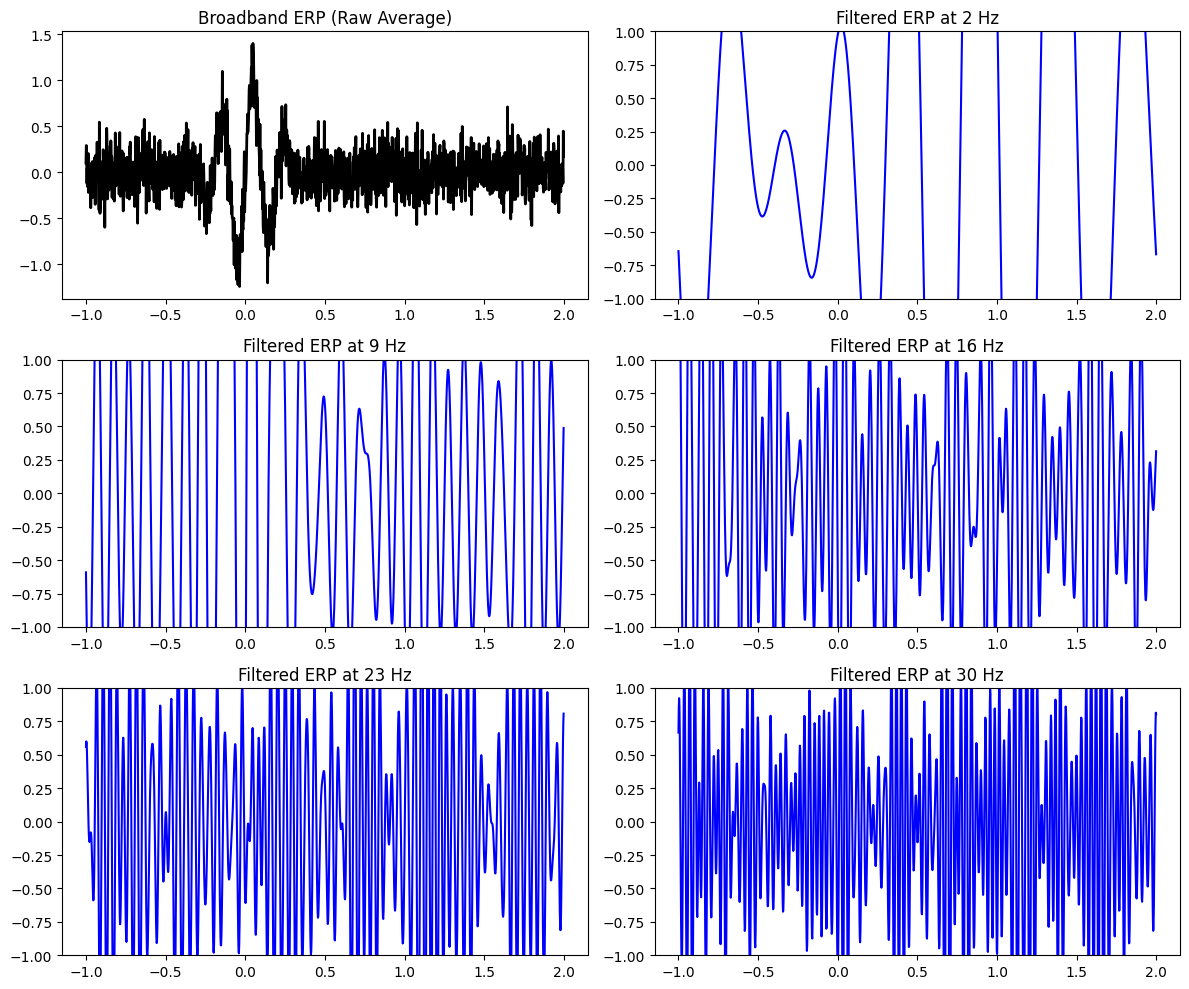

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. GENERATE FAKE CLINICAL DATA
srate = 500
time = np.arange(-1, 2, 1/srate)
trials = 100

# We inject a slow, phase-locked "P300-like" wave (5 Hz) into the noise
eeg_data = np.random.randn(trials, len(time)) * 2
eeg_data += np.sin(2 * np.pi * 5 * time) * np.exp(-(time**2)/0.05)

# ==========================================
# EXERCISE 3 & 4: Calculate the Broadband ERP
# ==========================================
broadband_erp = np.mean(eeg_data, axis=0)

# ==========================================
# EXERCISE 1: Create the Wavelet Family
# ==========================================
frex = np.linspace(2, 30, 5)  # [2.0, 9.0, 16.0, 23.0, 30.0] Hz
n_cycles = 6

# Set up the 6 subplots
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()

# Plot the Raw Broadband ERP
axes[0].plot(time, broadband_erp, 'k', linewidth=2)
axes[0].set_title("Broadband ERP (Raw Average)")

# ==========================================
# EXERCISE 2: Convolve and plot the real part
# ==========================================
for i, f in enumerate(frex):
    # Build the wavelet
    s = n_cycles / (2 * np.pi * f)
    wav_time = np.arange(-2, 2, 1/srate)
    wavelet = np.exp(1j * 2 * np.pi * f * wav_time) * np.exp(-(wav_time**2) / (2 * s**2))

    # Fast FFT Convolution
    n_conv = len(broadband_erp) + len(wavelet) - 1
    half_w = len(wavelet) // 2

    fft_erp = np.fft.fft(broadband_erp, n_conv)
    fft_wav = np.fft.fft(wavelet, n_conv)

    # TAKE THE REAL PART (Bandpass filtering)
    filtered_erp = np.real(np.fft.ifft(fft_erp * fft_wav))
    filtered_erp = filtered_erp[half_w : -half_w + 1] # Trim edges

    # Plot the result
    axes[i+1].plot(time, filtered_erp, 'b')
    axes[i+1].set_title(f"Filtered ERP at {f:.0f} Hz")
    axes[i+1].set_ylim([-1, 1])

plt.tight_layout()
plt.show()